In [416]:
# Create the spherical grid
from scipy.stats import vonmises

def create_sphere_grid(n_theta, n_phi):
    theta = np.linspace(0, np.pi, n_theta)  # Polar angle
    phi = np.linspace(0, 2*np.pi, n_phi)    # Azimuthal angle
    theta, phi = np.meshgrid(theta, phi)
    return theta, phi


def spherical_function(theta, phi):
    # Parameters for the Bingham distribution
    kappa = 10  # Concentration parameter
    center_theta = np.pi / 4

    def bingham_pdf(theta, kappa, loc):
        # Compute unnormalized PDF using a squared cosine term
        numerator = np.exp(kappa * np.cos(theta - loc)**2)
        # Approximate the normalization constant over theta in [0, pi]
        theta_grid = np.linspace(0, np.pi, 1000)
        norm = np.trapz(np.exp(kappa * np.cos(theta_grid - loc)**2), theta_grid)
        return numerator / norm

    # Compute the Bingham distribution on the sphere (ignoring phi dependence for simplicity)
    return bingham_pdf(theta, kappa, center_theta)

n_theta, n_phi = 200, 200
theta, phi = create_sphere_grid(n_theta, n_phi)

# Define the function on the sphere
func_values = spherical_function(theta, phi)


In [647]:
from dipy.reconst.shm import sph_harm_ind_list, real_sh_descoteaux, spherical_harmonics
from jax.scipy.special import sph_harm
import jax
import jax.numpy as jnp
import numpy as np

jax.config.update("jax_enable_x64", True)

In [684]:
from functools import partial


def real_sh_descoteaux_from_index_jax(m_values, l_values, theta, phi, *, sh_order_max=4, legacy=True):
    # In the cited paper, the basis is defined without the absolute value
    if legacy:
        sh = sph_harm(jnp.abs(m_values), l_values, phi, theta, n_max=sh_order_max)
    else:
        sh = sph_harm(m_values, l_values, phi, theta, n_max=sh_order_max)

    real_sh = jnp.where(m_values > 0, sh.imag, sh.real)
    real_sh *= jnp.where(m_values == 0, 1.0, np.sqrt(2))

    return real_sh

def real_sh(sh_order_max, theta, phi, *, full_basis=False, legacy=True):
    with jax.ensure_compile_time_eval():
        m_value, l_value = sph_harm_ind_list(sh_order_max, full_basis=full_basis)
    m_value = jnp.asarray(m_value).reshape(-1,1)
    l_value = jnp.asarray(l_value).reshape(-1,1)
    phi = jnp.asarray(phi).reshape(-1,1)
    theta = jnp.asarray(theta).reshape(-1,1)

    _real_sph_harm = partial(real_sh_descoteaux_from_index_jax, sh_order_max=sh_order_max, legacy=legacy)
    real_sh = jax.vmap(jax.vmap(_real_sph_harm, in_axes=(0,0, None,None)), in_axes=(None,None,0,0))(m_value, l_value, theta, phi)

    return real_sh.squeeze(-1), m_value.squeeze(-1), l_value.squeeze(-1)


def sh_coefficients(func_values, sh_basis):
    # Compute the SH coefficients
    sh_coeff = np.linalg.lstsq(sh_basis, func_values.flatten(), rcond=None)[0]
    return sh_coeff


In [685]:
from dipy.core.sphere import HemiSphere, Sphere

xyz = jax.random.normal(jax.random.PRNGKey(0), (80_000, 3))
xyz /= jnp.linalg.norm(xyz, axis=-1, keepdims=True)

sphere = Sphere(xyz=xyz)


In [755]:
# D = jax.random.normal(jax.random.PRNGKey(0), (3,3))
# D = D @ D.T
D = jnp.eye(3)*0.1

def func(theta, phi):
    vec = jnp.array([jnp.sin(theta) * jnp.cos(phi), jnp.sin(theta) * jnp.sin(phi), jnp.cos(theta)])
    return jnp.exp(-jnp.dot(vec, D @ vec))

In [756]:
func_values2 = jax.vmap(func)(sphere.theta, sphere.phi)

In [757]:
r_sh, m_value, l_value = real_sh(4, sphere.theta, sphere.phi, full_basis=True)

In [758]:
m_value

Array([ 0, -1,  0,  1, -2, -1,  0,  1,  2, -3, -2, -1,  0,  1,  2,  3, -4,
       -3, -2, -1,  0,  1,  2,  3,  4], dtype=int64)

In [759]:
sh_coeff = np.linalg.lstsq(r_sh, jnp.log(-jnp.log(func_values2)), rcond=None)[0]

In [760]:
sh_coeff

array([-8.16245163e+00,  3.78632954e-15, -2.18476073e-15,  1.58518006e-15,
        2.39111080e-15,  3.34111815e-16, -1.19336687e-15,  2.41256965e-16,
        3.72259305e-15,  6.16451399e-17,  1.33031232e-15,  1.80345915e-16,
        1.84556899e-15,  4.08688997e-16,  1.11440140e-15, -8.88321181e-16,
        4.07386116e-15,  9.24173225e-16, -4.30444698e-16, -1.72299450e-15,
        3.28534752e-15, -6.47712106e-16, -5.77502136e-16, -2.69271063e-15,
        1.59516703e-15])

In [764]:
1. / np.tan(0.99 * (np.pi / 2.0))

0.015709255323664885

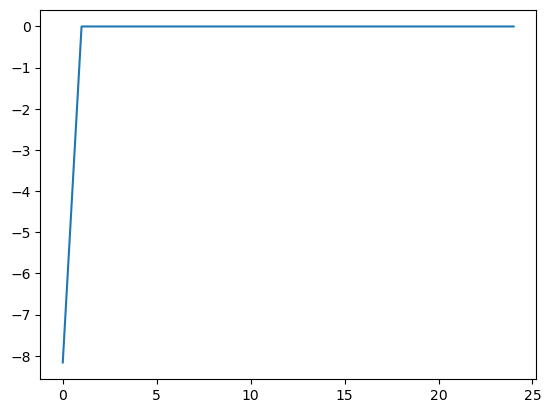

In [761]:
plt.plot(sh_coeff)

In [754]:
jnp.trace(D) * 1/(jnp.sqrt(4*jnp.pi))

Array(1.69256875, dtype=float64)

In [646]:
2*D[-1,-1] - D[0,0] - D[1,1]

Array(0., dtype=float32)

In [438]:
func_values_reconstructed = np.dot(r_sh, sh_coeff).reshape(n_theta, n_phi)

In [439]:
jnp.mean((func_values_reconstructed - func_values)**2)

Array(0.00197517, dtype=float32)

In [423]:
jnp.allclose(real_sh_descoteaux(4, theta, phi)[0], r_sh)

TypeError: sub got incompatible shapes for broadcasting: (40000, 15), (40000, 91).

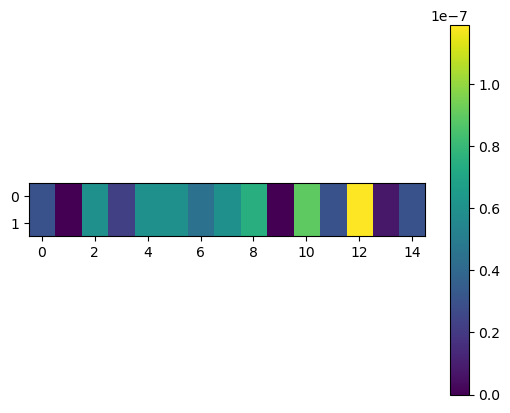

In [357]:
import matplotlib.pyplot as plt
plt.imshow(jnp.abs(real_sh_descoteaux(4, theta, phi)[0] - r_sh))
plt.colorbar()